In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast  # to safely parse the latency arrays

In [88]:
csv_file = "atomd_db-data_latency_experiments_Release.csv"
df = pd.read_csv(csv_file, sep=";")

# Quick sanity check
df.head()


,Id,experiment_id,experiment_name,source_id,target_id,strategy,emission_mode,total_samples,latency_samples,average_latency,minimum_latency,maximum_latency,standard_deviation_of_latency
0,1,1768844539660,RTT - Ping Emission: SERIES - N.Pings: 1000,0a3f31673eb194e8,5CTP,P2P_STAR,SERIES,1000,"[303.743616,242.384385,217.681538,235.408077,2...",265.604140,44.462769,1458.103693,114.529825
1,2,1768844813809,RTT - Ping Emission: SERIES - N.Pings: 100,0a3f31673eb194e8,5CTP,P2P_STAR,SERIES,100,"[495.165231,238.214385,223.979077,305.032,144....",214.480647,96.956000,749.102462,88.404722
2,3,1768844896712,RTT - Ping Emission: SERIES - N.Pings: 10,0a3f31673eb194e8,5CTP,P2P_STAR,SERIES,10,"[212.921308,206.469924,95.706461,183.378077,22...",176.304300,95.706461,226.096846,40.097720
3,4,1768844901909,RTT - Ping Emission: SERIES - N.Pings: 10,0a3f31673eb194e8,5CTP,P2P_STAR,SERIES,10,"[372.621231,236.161615,126.558154,205.219077,1...",205.907262,125.271615,372.621231,78.177512
4,5,1768844907308,RTT - Ping Emission: SERIES - N.Pings: 10,0a3f31673eb194e8,5CTP,P2P_STAR,SERIES,10,"[278.704,178.542462,134.107384,127.054693,268....",201.898669,127.054693,278.704000,48.033508


In [89]:
df["latency_samples"] = df["latency_samples"].apply(ast.literal_eval)

# Verify parsing
df["latency_samples"].iloc[0]


[303.743616,
 242.384385,
 217.681538,
 235.408077,
 237.459077,
 200.68423,
 218.717615,
 206.626077,
 421.083,
 245.700846,
 235.170693,
 213.505615,
 216.573616,
 227.659,
 364.526385,
 220.325616,
 250.171384,
 238.601923,
 249.059154,
 382.349615,
 253.692615,
 219.144385,
 226.865231,
 378.980846,
 268.054846,
 225.858692,
 225.187077,
 245.481308,
 198.471462,
 260.681538,
 217.724077,
 644.814154,
 353.291,
 289.814154,
 221.546461,
 216.116231,
 218.813538,
 217.944,
 374.267693,
 221.776616,
 146.984077,
 802.236,
 208.371077,
 233.472308,
 221.288,
 232.576692,
 241.778769,
 207.827385,
 350.755077,
 236.074539,
 196.686153,
 227.262461,
 214.541846,
 259.841,
 216.473307,
 253.420923,
 341.025539,
 267.344,
 151.110462,
 279.667308,
 229.040615,
 216.003077,
 265.069462,
 243.925,
 628.199693,
 262.177461,
 669.229154,
 427.624615,
 567.397231,
 309,
 878.368615,
 678.508,
 646.879692,
 643.504846,
 228.725923,
 333.588385,
 242.442462,
 104.367077,
 190.387461,
 218.693538

In [90]:
def compute_metrics(samples):
    samples = np.array(samples)
    return pd.Series({
        "n_samples": len(samples),
        "mean_latency": samples.mean(),
        "min_latency": samples.min(),
        "max_latency": samples.max(),
        "p50_latency": np.percentile(samples, 50),
        "p95_latency": np.percentile(samples, 95),
        "jitter_std": samples.std(ddof=0)
    })

metrics_df = df["latency_samples"].apply(compute_metrics)

df_metrics = pd.concat([df, metrics_df], axis=1)
df_metrics.head()


,Id,experiment_id,experiment_name,source_id,target_id,strategy,emission_mode,total_samples,latency_samples,average_latency,minimum_latency,maximum_latency,standard_deviation_of_latency,n_samples,mean_latency,min_latency,max_latency,p50_latency,p95_latency,jitter_std
0,1,1768844539660,RTT - Ping Emission: SERIES - N.Pings: 1000,0a3f31673eb194e8,5CTP,P2P_STAR,SERIES,1000,"[303.743616, 242.384385, 217.681538, 235.40807...",265.604140,44.462769,1458.103693,114.529825,1000.0,265.604140,44.462769,1458.103693,226.932808,428.507427,114.529825
1,2,1768844813809,RTT - Ping Emission: SERIES - N.Pings: 100,0a3f31673eb194e8,5CTP,P2P_STAR,SERIES,100,"[495.165231, 238.214385, 223.979077, 305.032, ...",214.480647,96.956000,749.102462,88.404722,100.0,214.480647,96.956000,749.102462,206.839538,356.192800,88.404722
2,3,1768844896712,RTT - Ping Emission: SERIES - N.Pings: 10,0a3f31673eb194e8,5CTP,P2P_STAR,SERIES,10,"[212.921308, 206.469924, 95.706461, 183.378077...",176.304300,95.706461,226.096846,40.097720,10.0,176.304300,95.706461,226.096846,188.278346,220.167854,40.097720
3,4,1768844901909,RTT - Ping Emission: SERIES - N.Pings: 10,0a3f31673eb194e8,5CTP,P2P_STAR,SERIES,10,"[372.621231, 236.161615, 126.558154, 205.21907...",205.907262,125.271615,372.621231,78.177512,10.0,205.907262,125.271615,372.621231,213.711692,332.713812,78.177512
4,5,1768844907308,RTT - Ping Emission: SERIES - N.Pings: 10,0a3f31673eb194e8,5CTP,P2P_STAR,SERIES,10,"[278.704, 178.542462, 134.107384, 127.054693, ...",201.898669,127.054693,278.704000,48.033508,10.0,201.898669,127.054693,278.704000,194.302000,273.964842,48.033508


In [91]:
summary = (
    df_metrics
    .groupby(["strategy", "emission_mode"])
    .agg(
        mean_latency=("mean_latency", "mean"),
        p95_latency=("p95_latency", "mean"),
        p50_latency=("p50_latency", "mean"),
        jitter=("jitter_std", "mean"),
        experiments=("Id", "count")
    )
    .reset_index()
)

summary


,strategy,emission_mode,mean_latency,p95_latency,p50_latency,jitter,experiments
0,P2P_STAR,PARALLEL,1848.948090,2841.411299,1979.932426,744.028248,16
1,P2P_STAR,SERIES,261.931886,307.544529,259.087667,30.770274,12


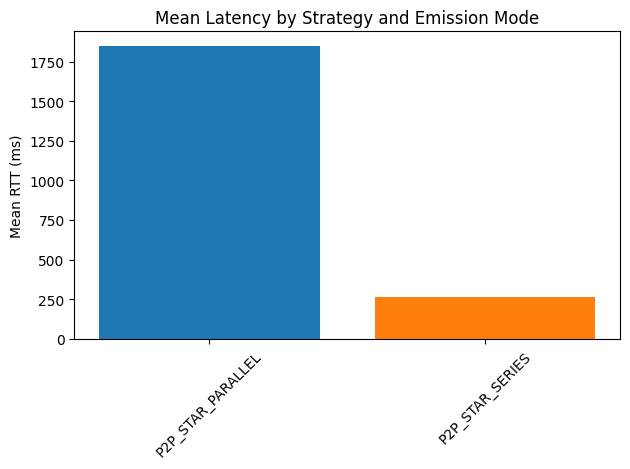

In [92]:
plt.figure()
for mode in summary["emission_mode"].unique():
    subset = summary[summary["emission_mode"] == mode]
    plt.bar(
        subset["strategy"] + "_" + mode,
        subset["mean_latency"],
        label=mode
    )

plt.ylabel("Mean RTT (ms)")
plt.title("Mean Latency by Strategy and Emission Mode")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [103]:
df_long = df_metrics.explode("latency_samples")
df_long["latency_samples"] = df_long["latency_samples"].astype(float)

experiment_means = (
    df_long
    .groupby("experiment_name")["latency_samples"]
    .mean()
)

THRESHOLD_MS = 1000.0

fast_experiments = experiment_means[experiment_means <= THRESHOLD_MS].index
slow_experiments = experiment_means[experiment_means > THRESHOLD_MS].index

def plot_violin_subset(df_long, experiment_names, title):
    subsets = [
        df_long[df_long["experiment_name"] == name]["latency_samples"].values
        for name in experiment_names
    ]

    plt.figure(figsize=(14, 6))

    plt.violinplot(
        subsets,
        showmeans=True,
        showmedians=True,
        showextrema=True
    )

    # overlay raw samples
    for i, name in enumerate(experiment_names, start=1):
        samples = df_long[df_long["experiment_name"] == name]["latency_samples"]

    plt.xticks(
        range(1, len(experiment_names) + 1),
        experiment_names,
        rotation=45,
        ha="right"
    )

    plt.ylabel("RTT (ms)")
    plt.title(title)
    plt.tight_layout()
    plt.show()


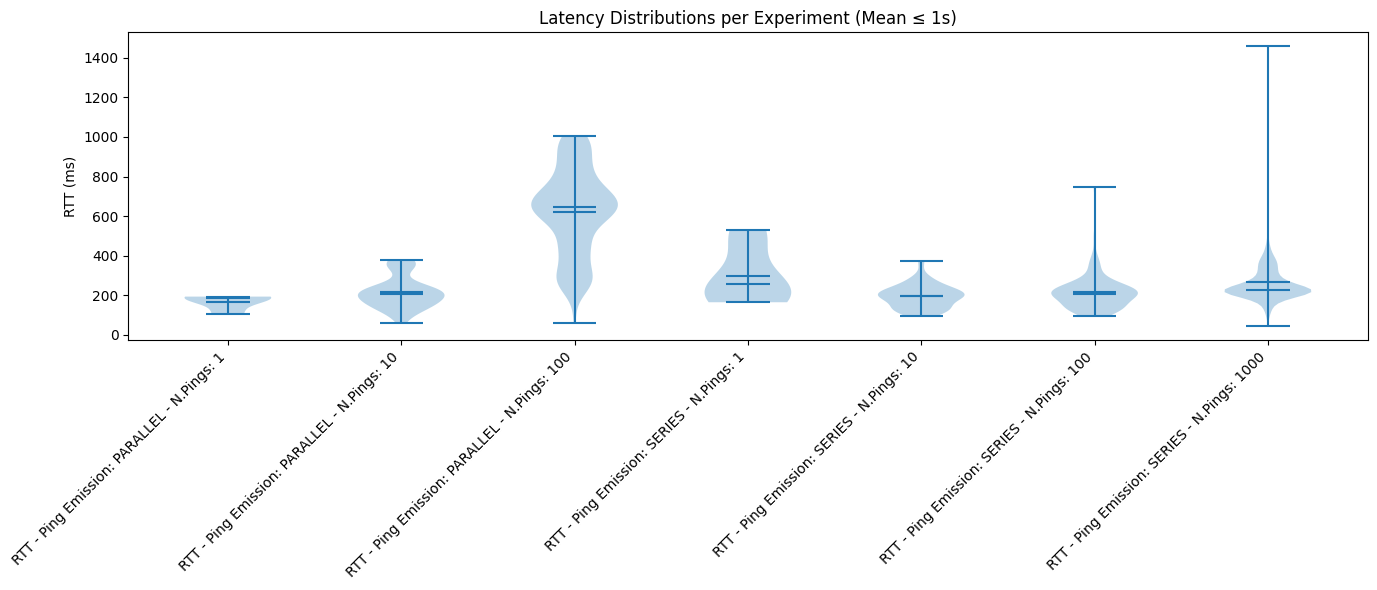

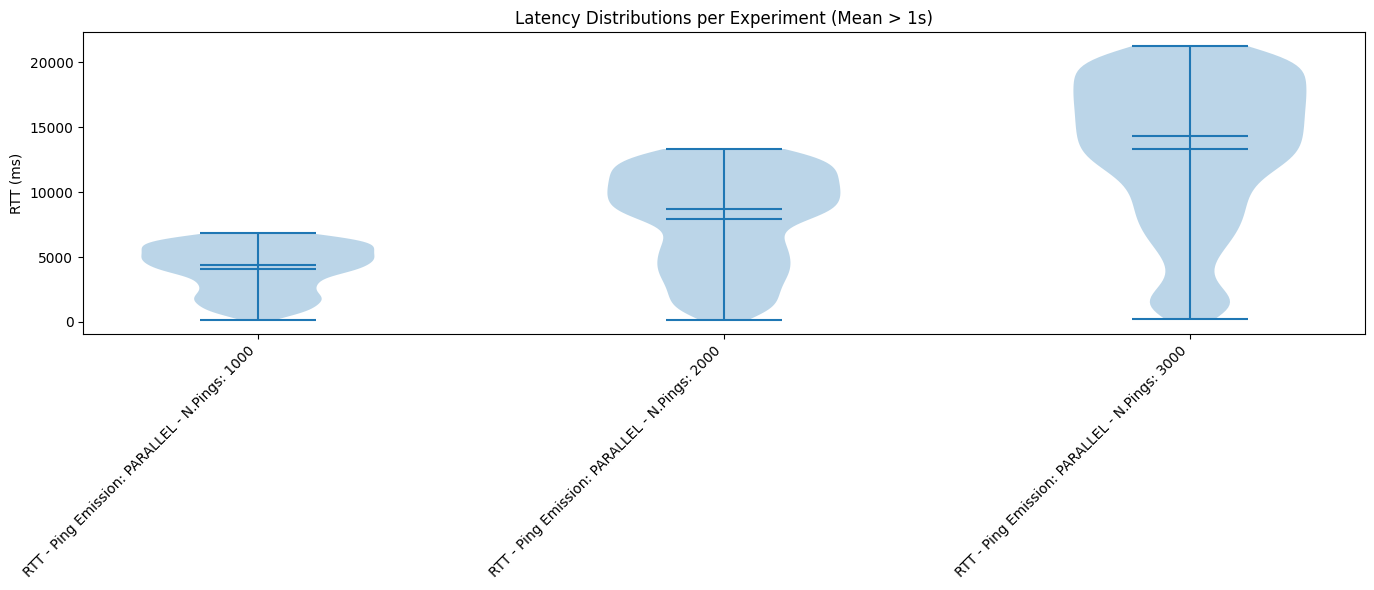

In [104]:
plot_violin_subset(
    df_long,
    fast_experiments,
    "Latency Distributions per Experiment (Mean ≤ 1s)"
)

plot_violin_subset(
    df_long,
    slow_experiments,
    "Latency Distributions per Experiment (Mean > 1s)"
)


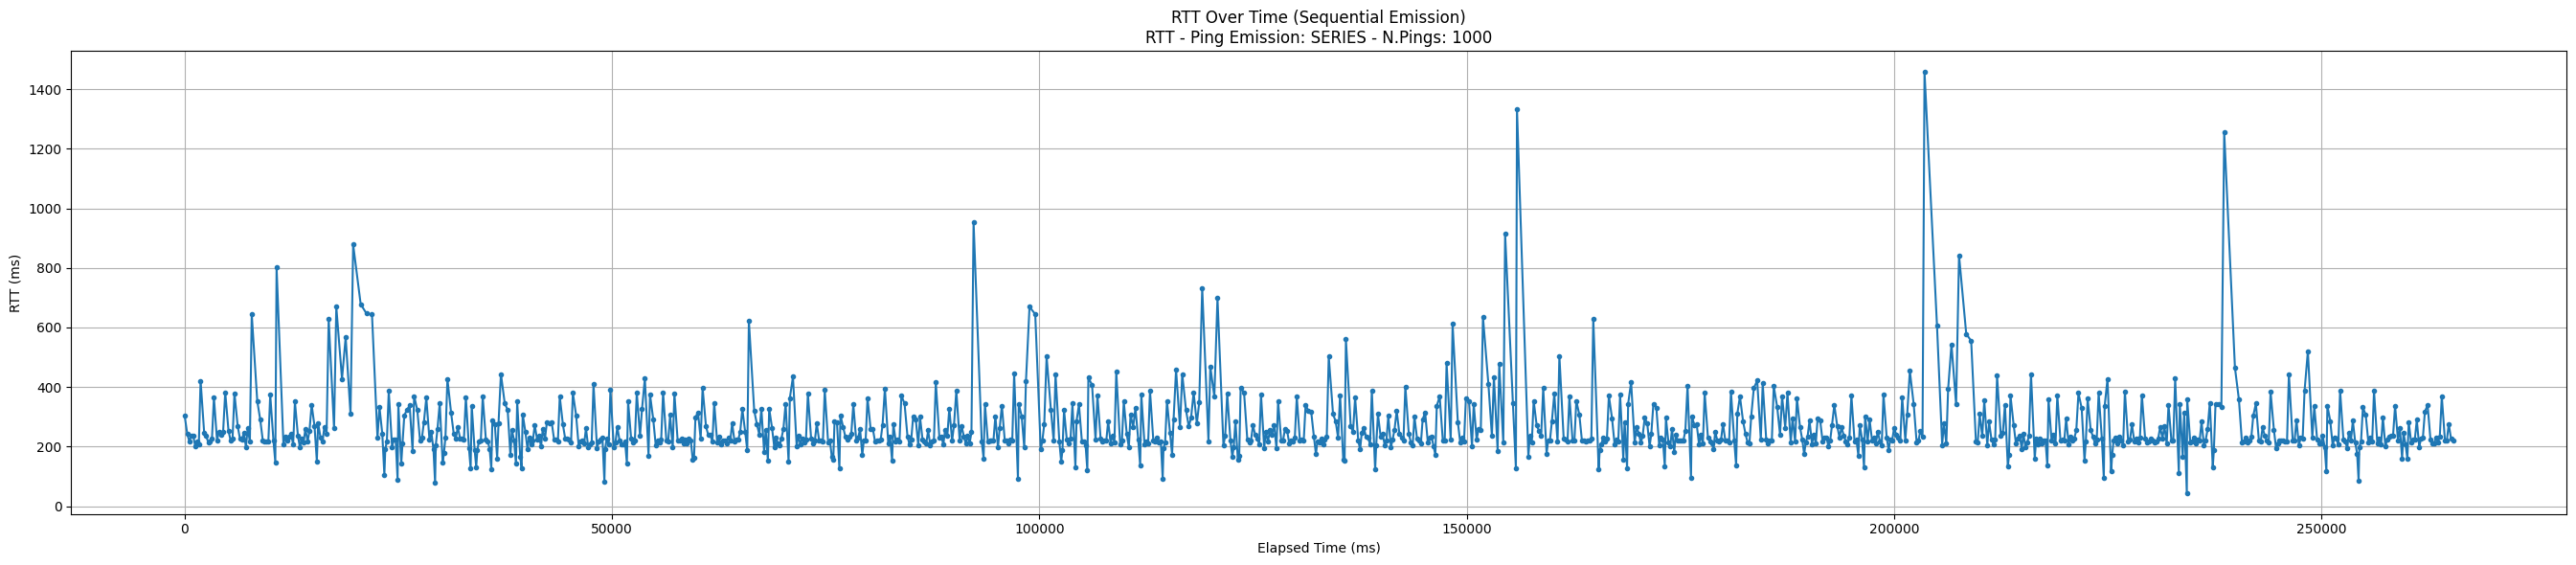

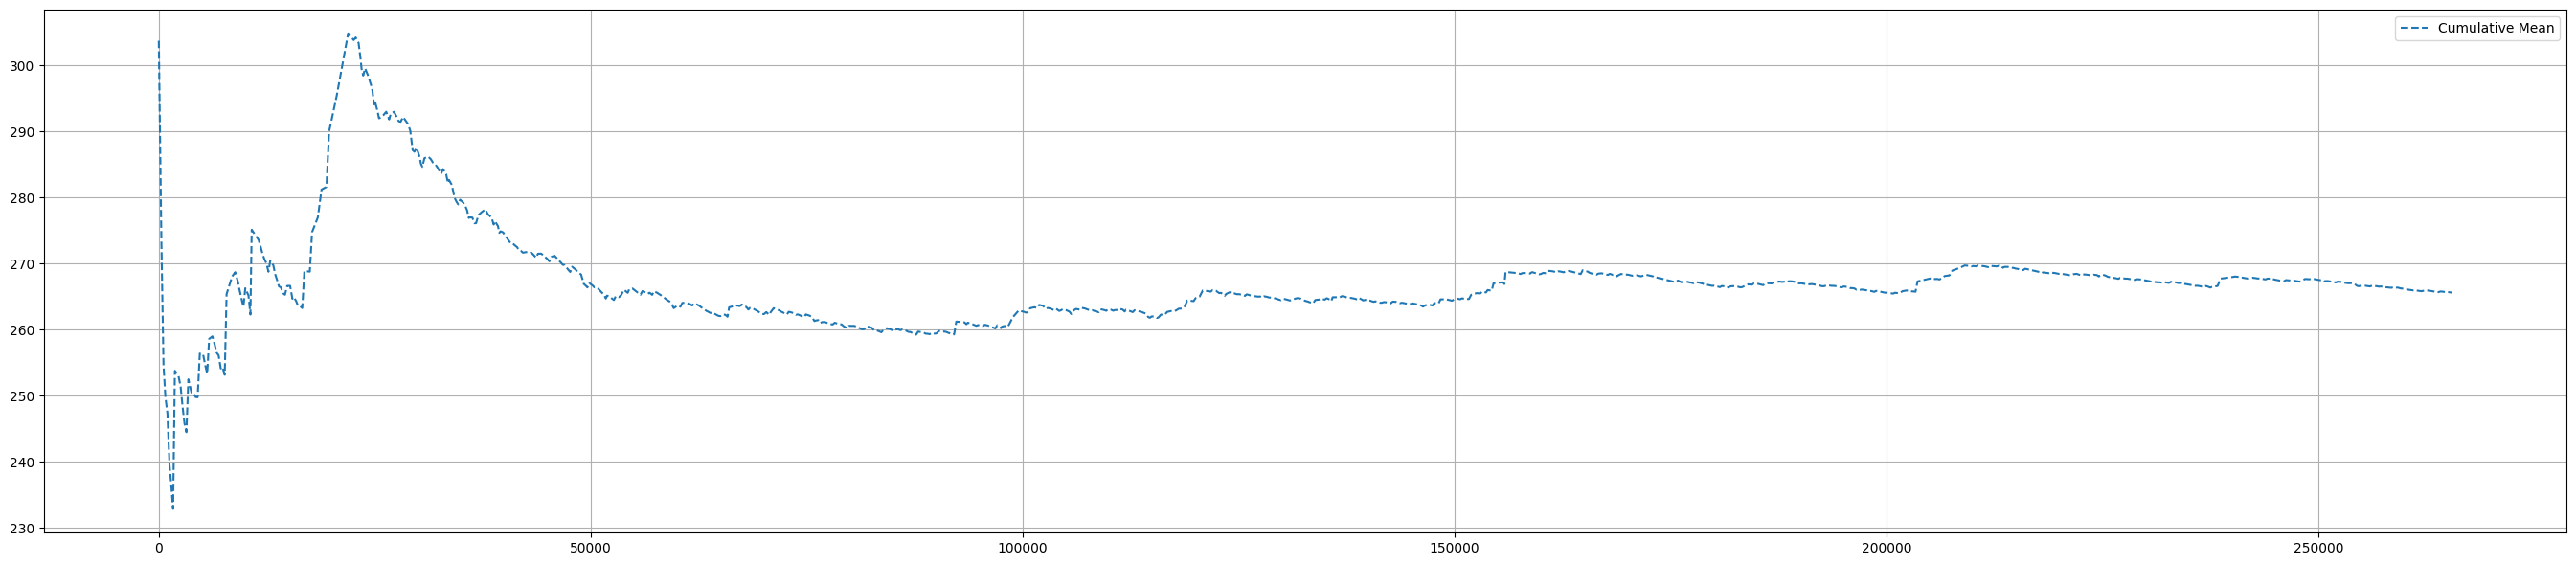

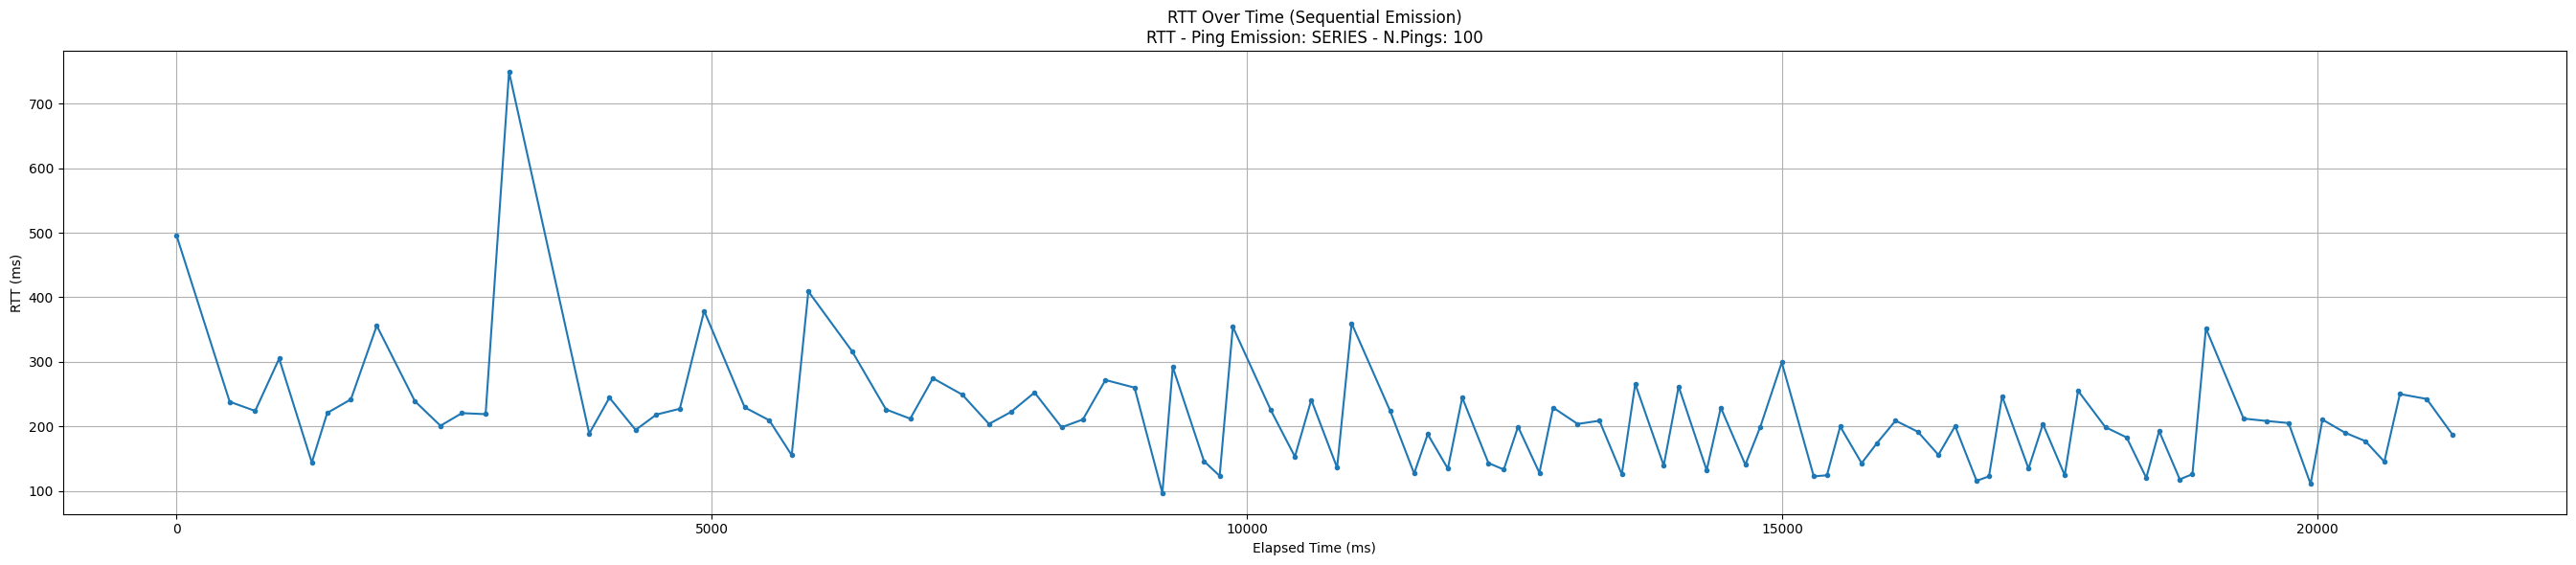

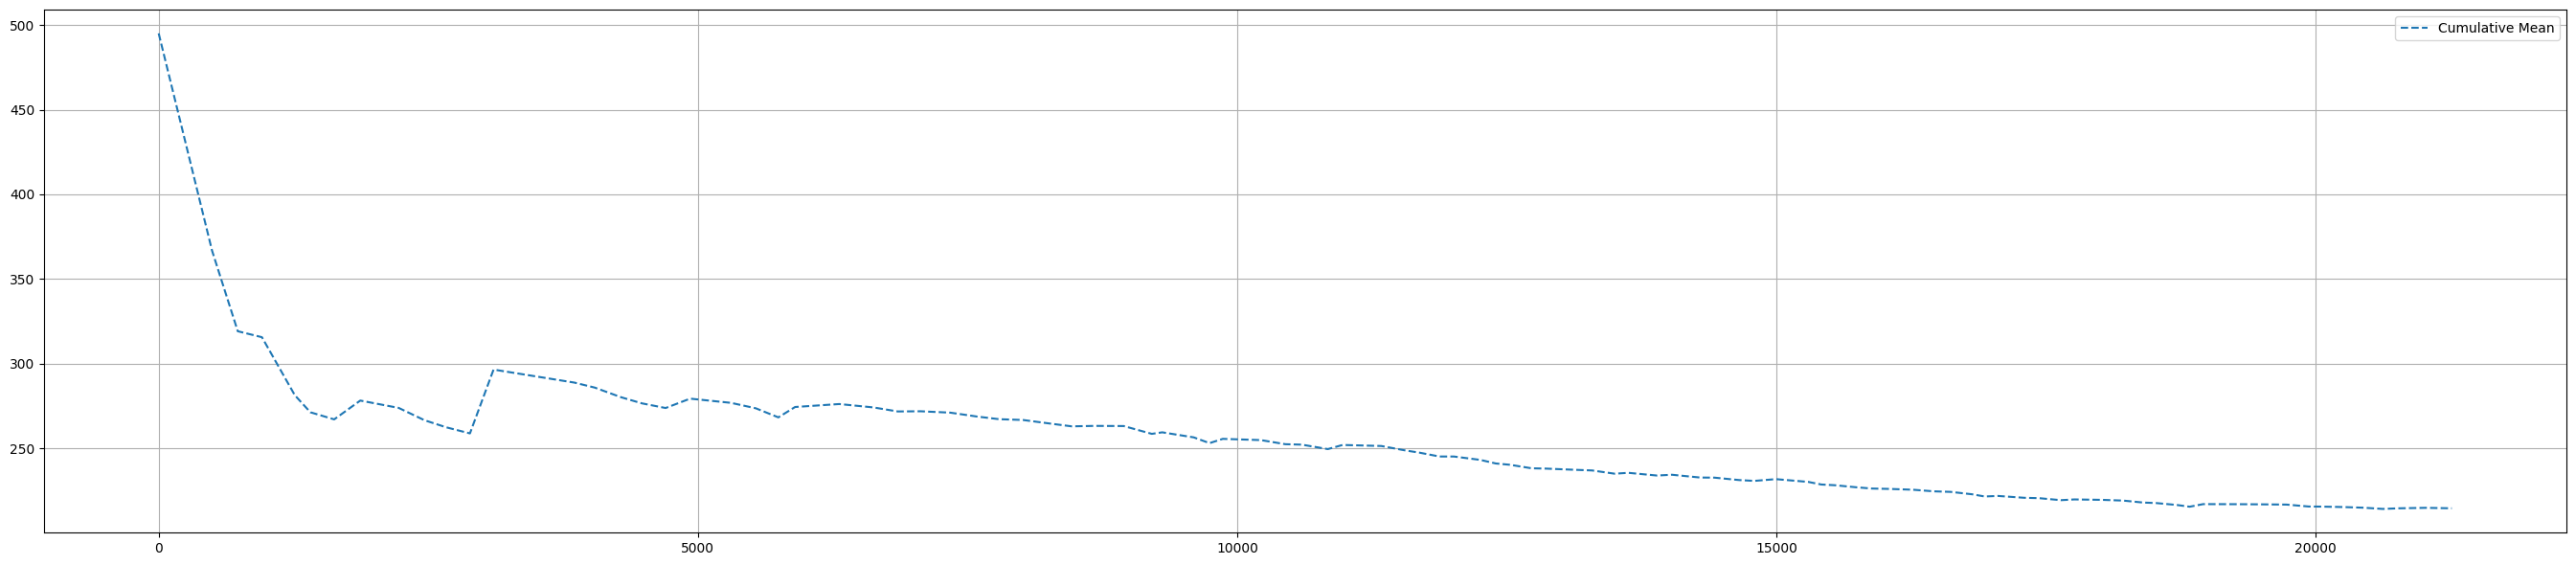

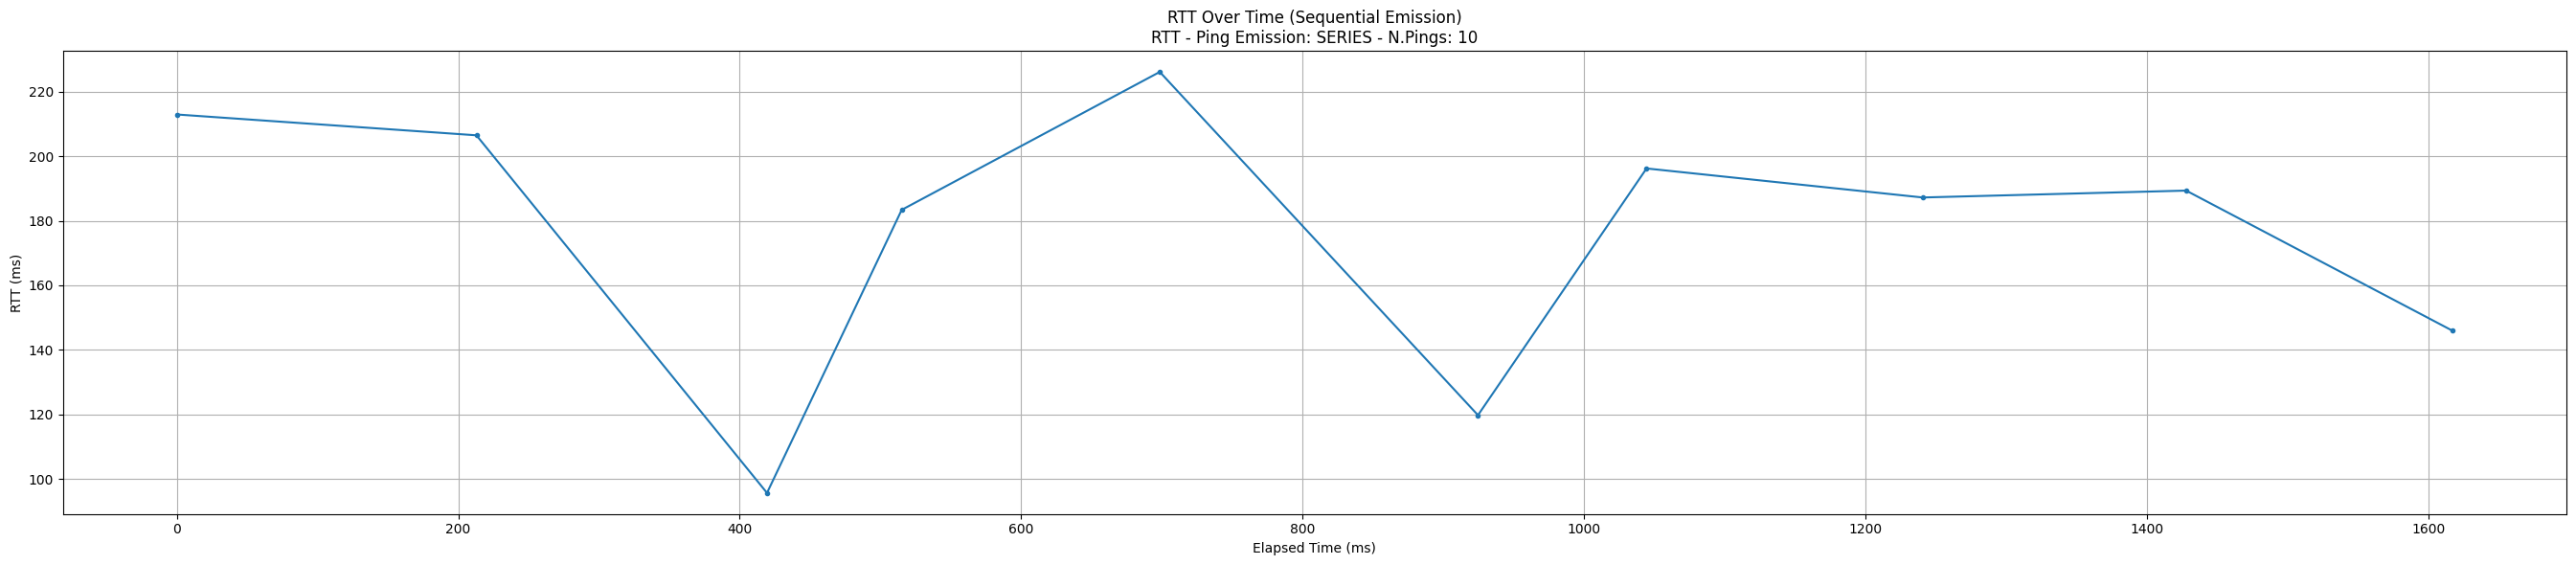

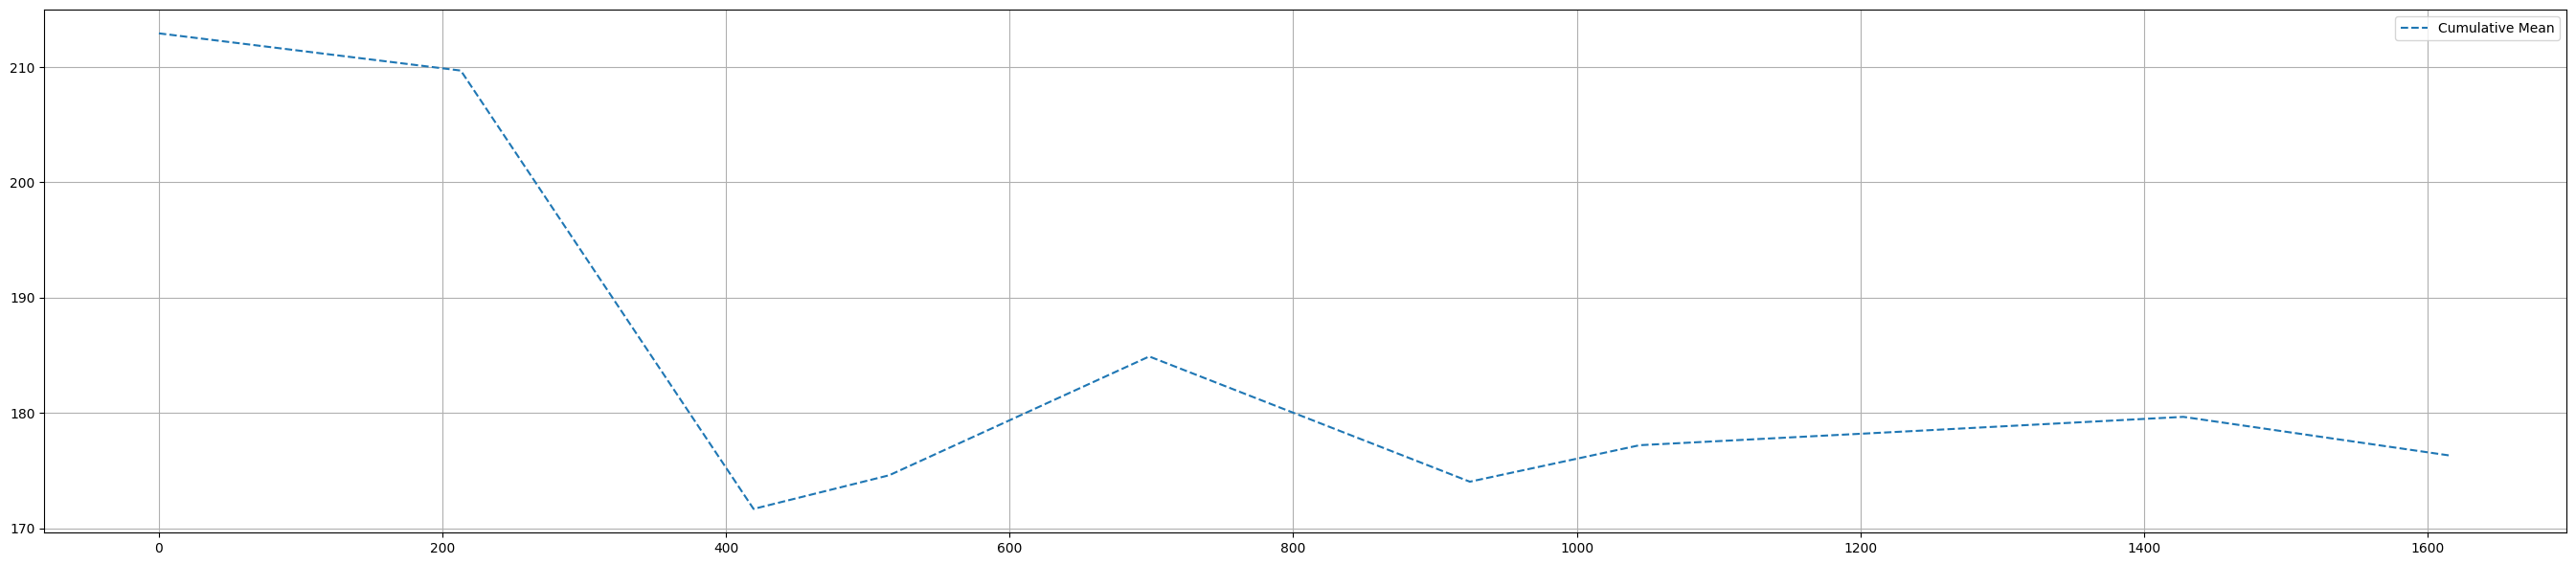

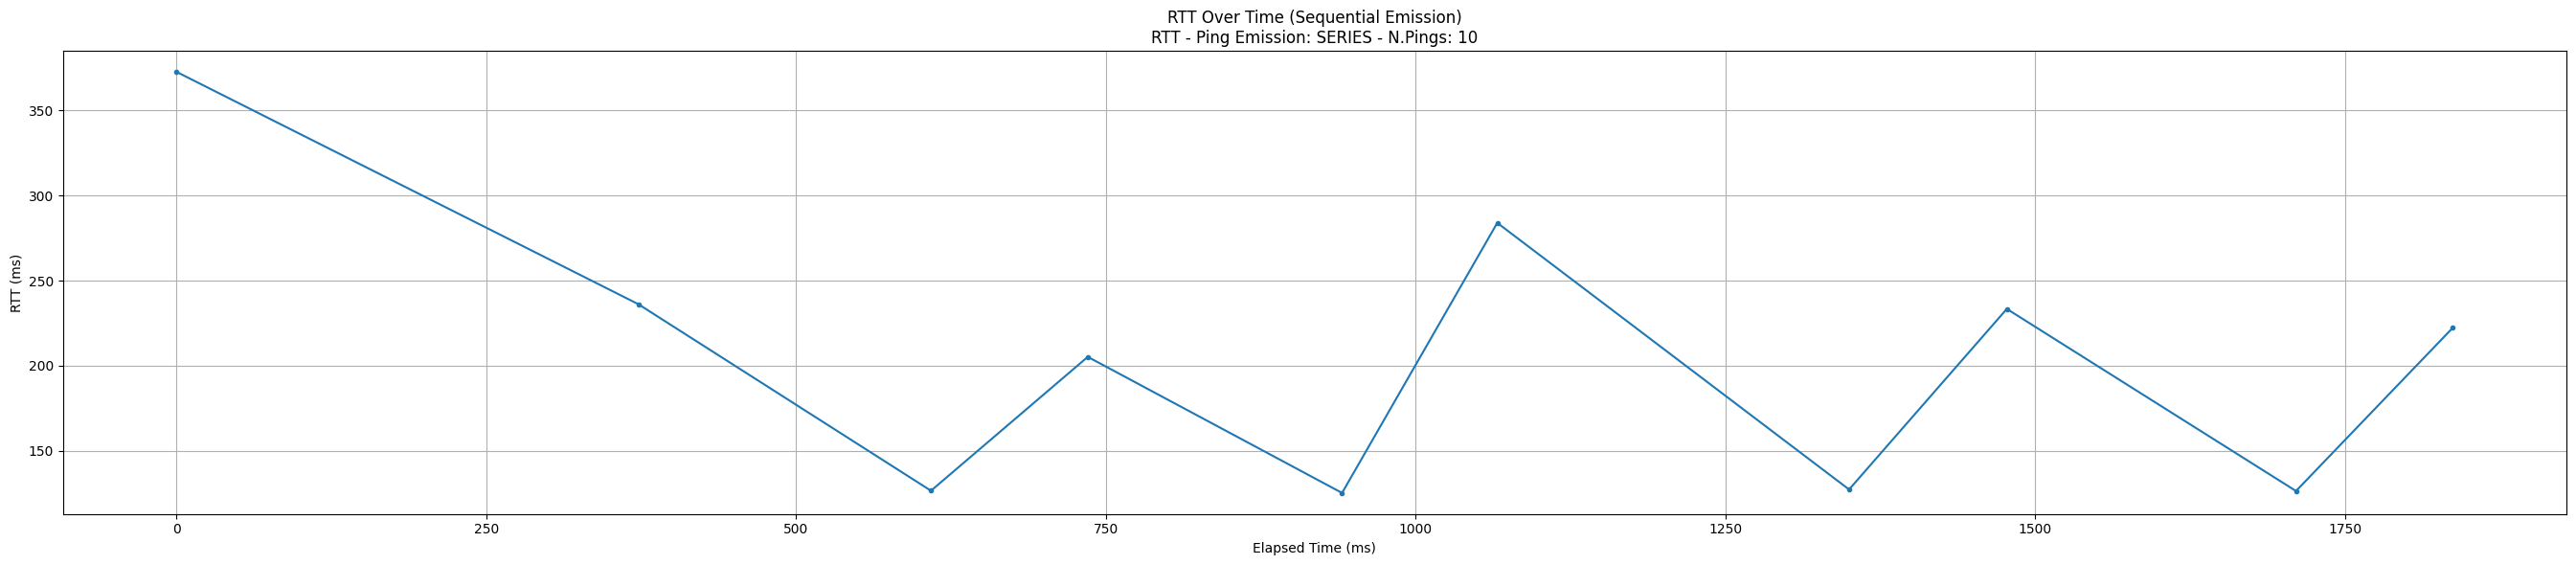

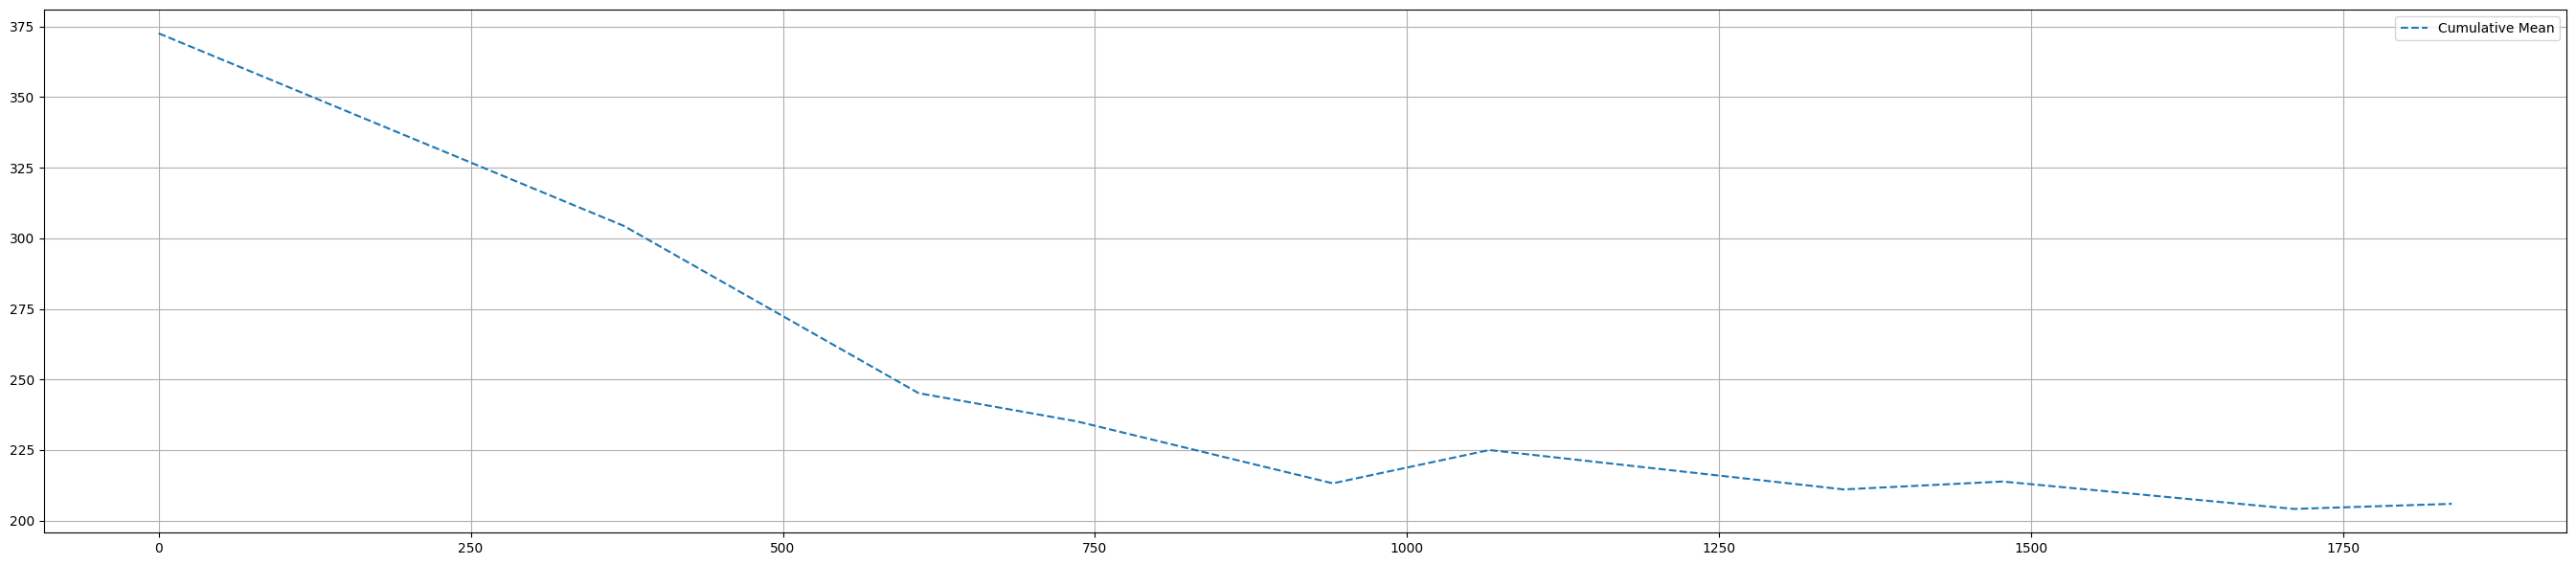

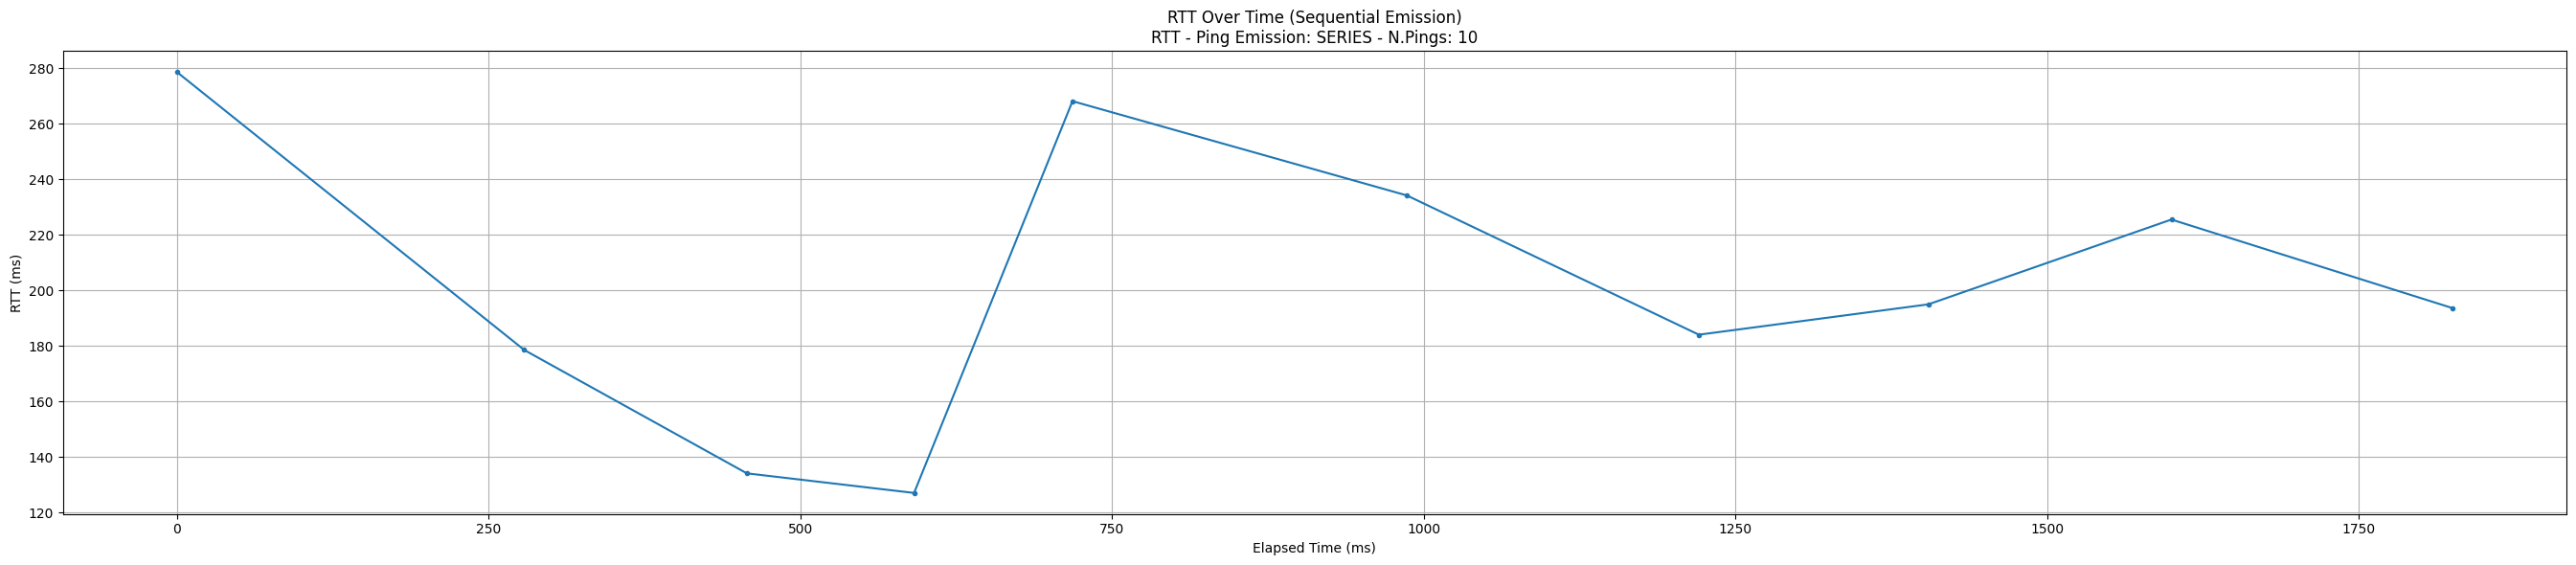

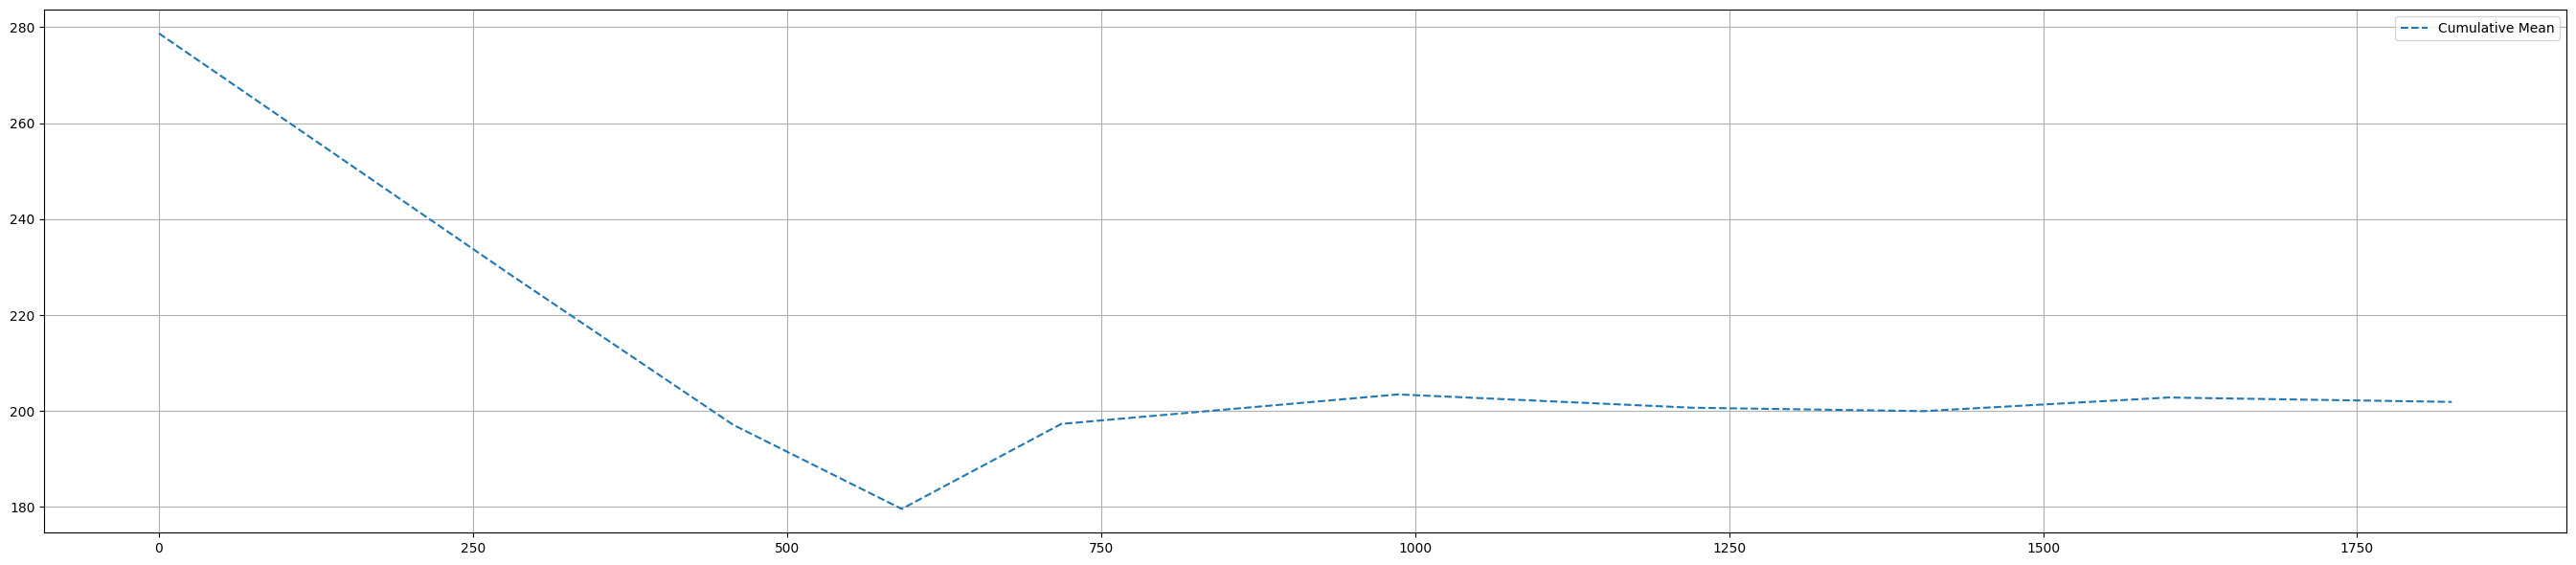

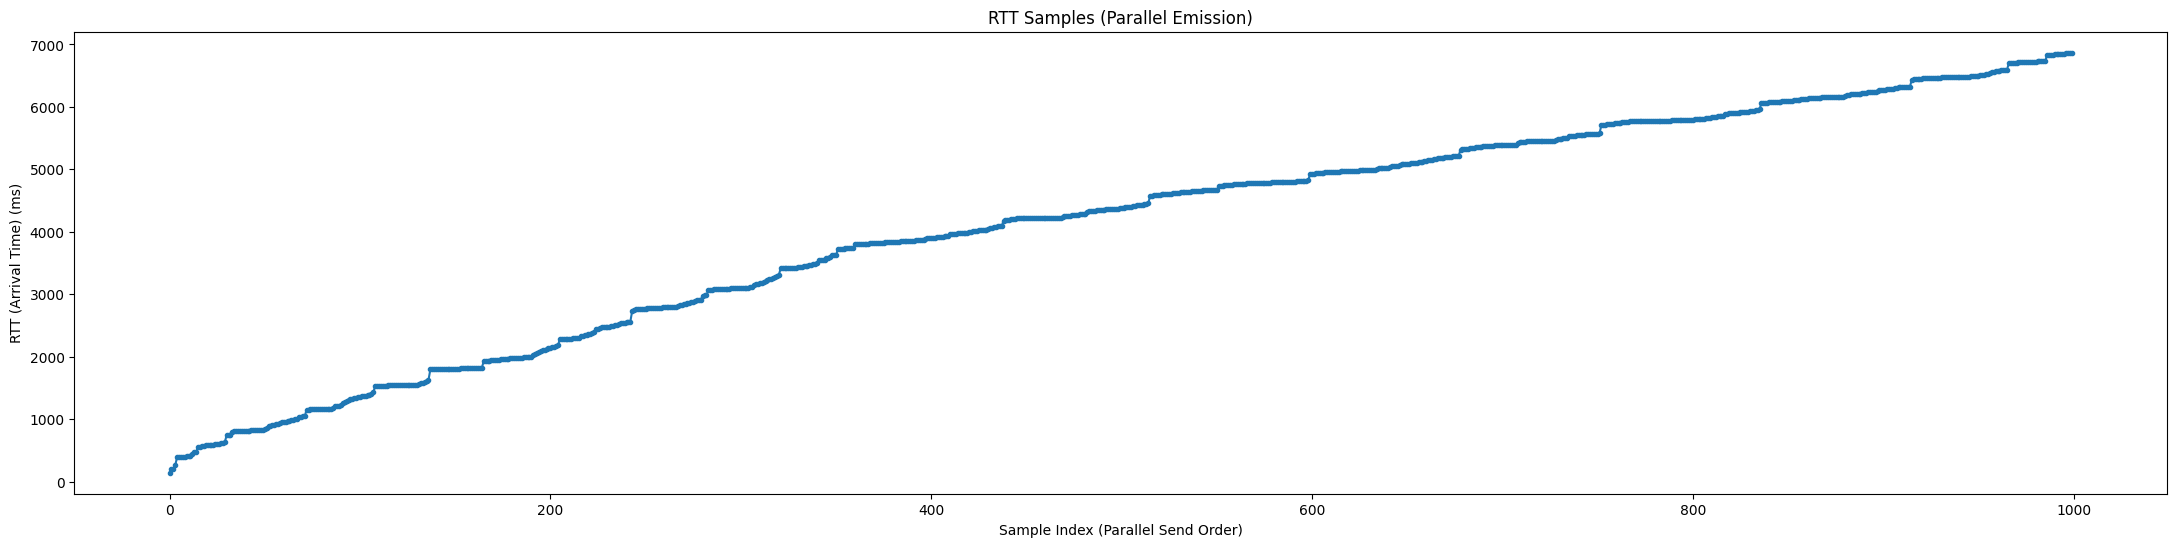

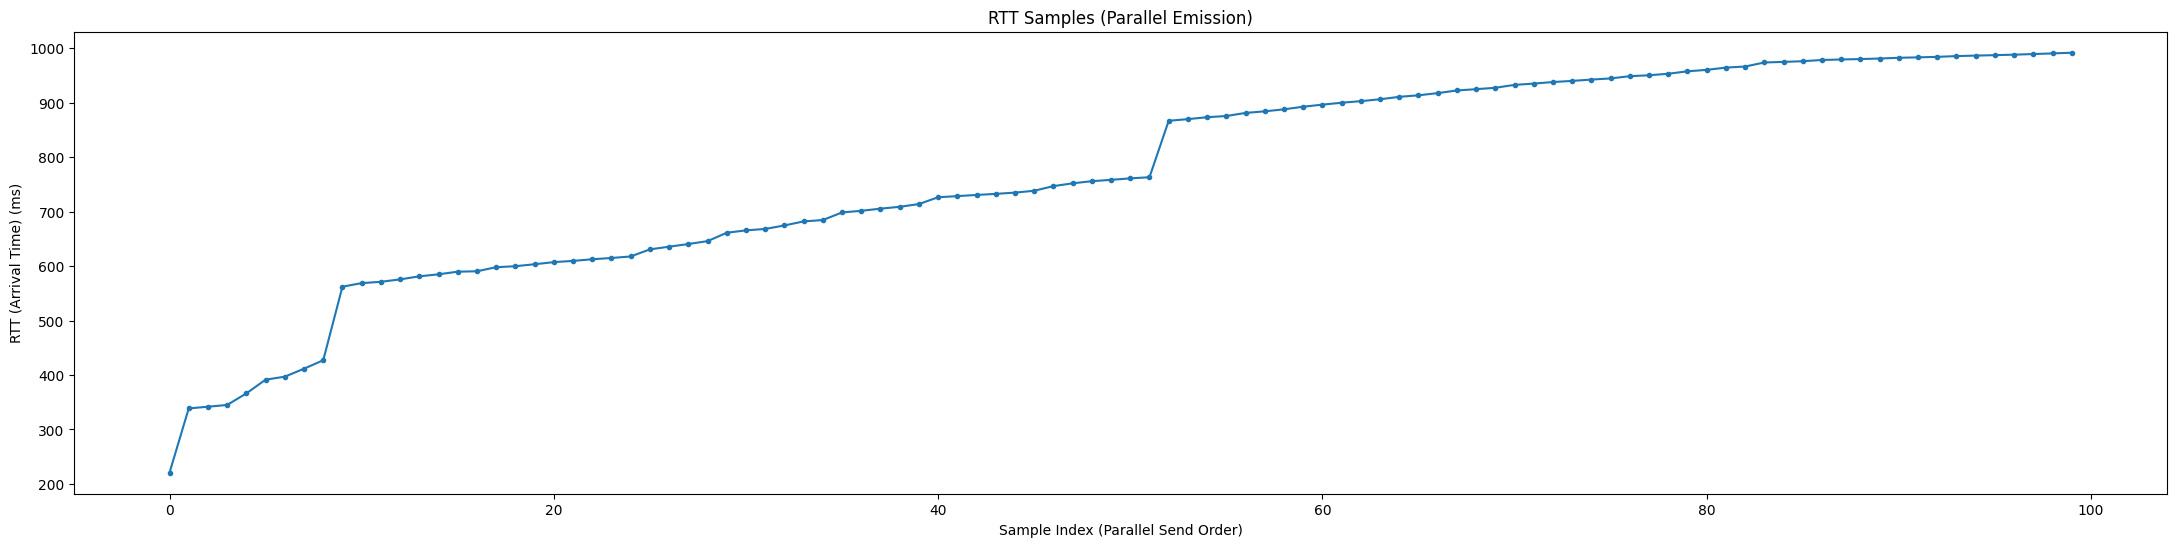

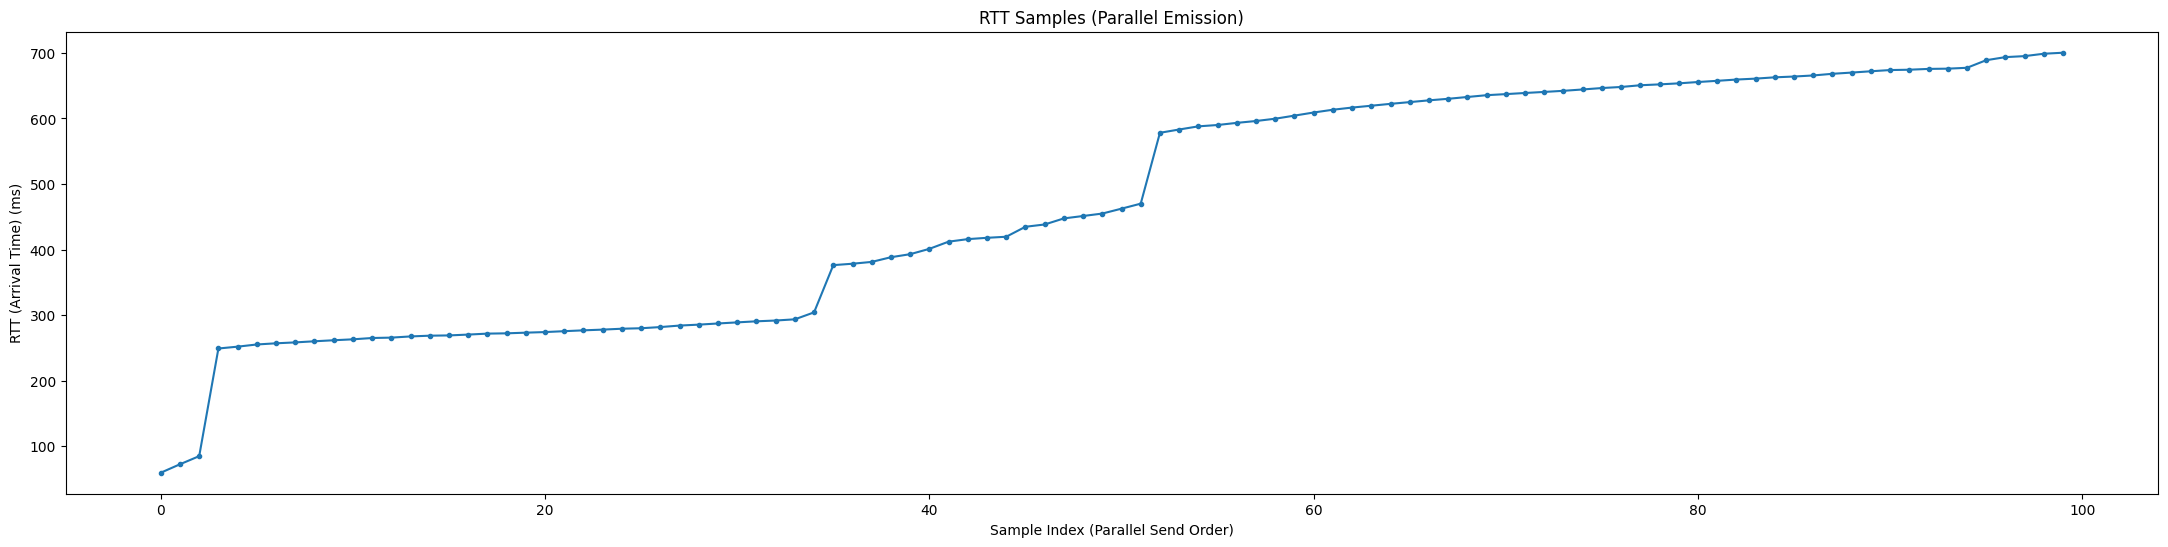

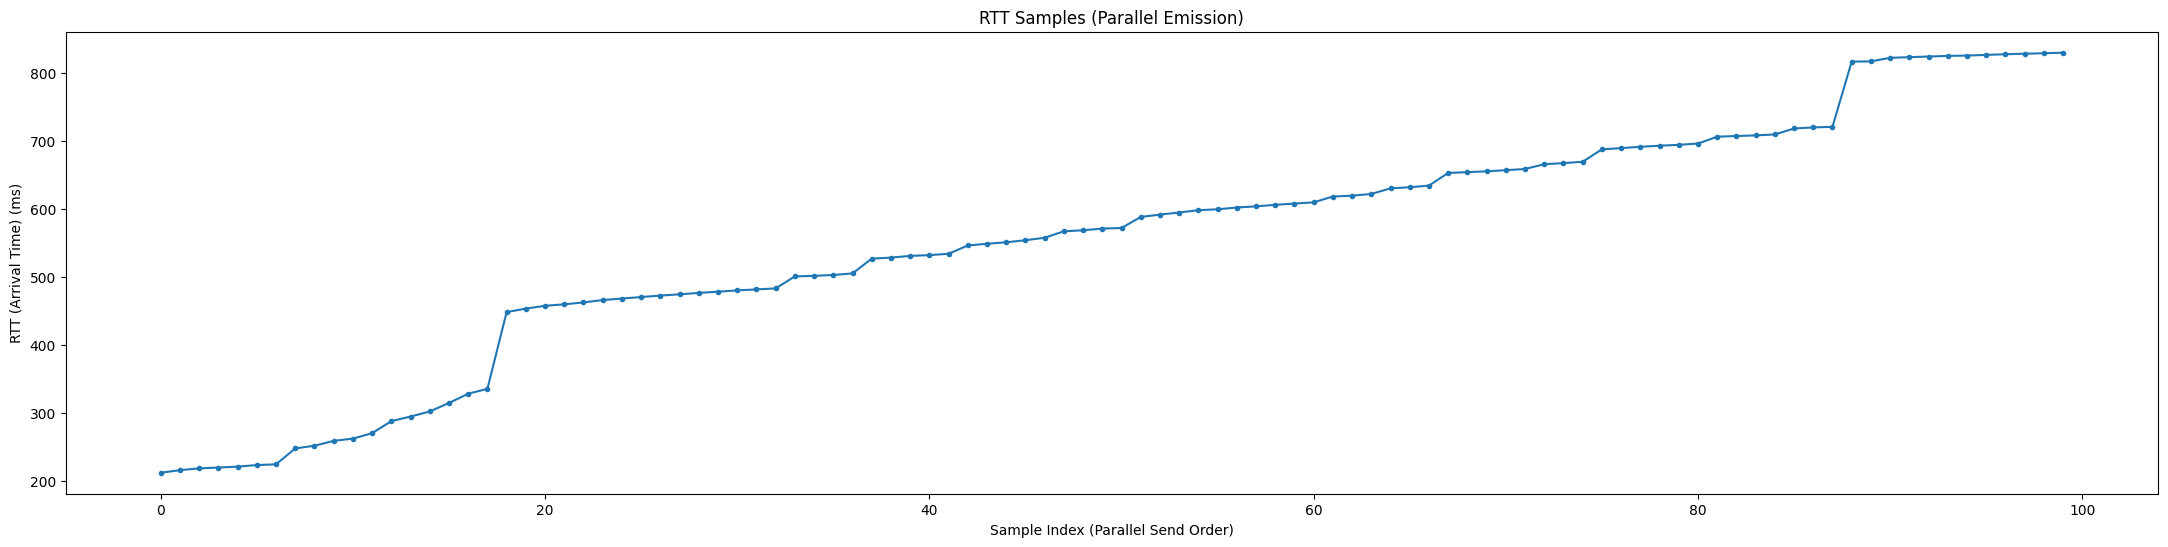

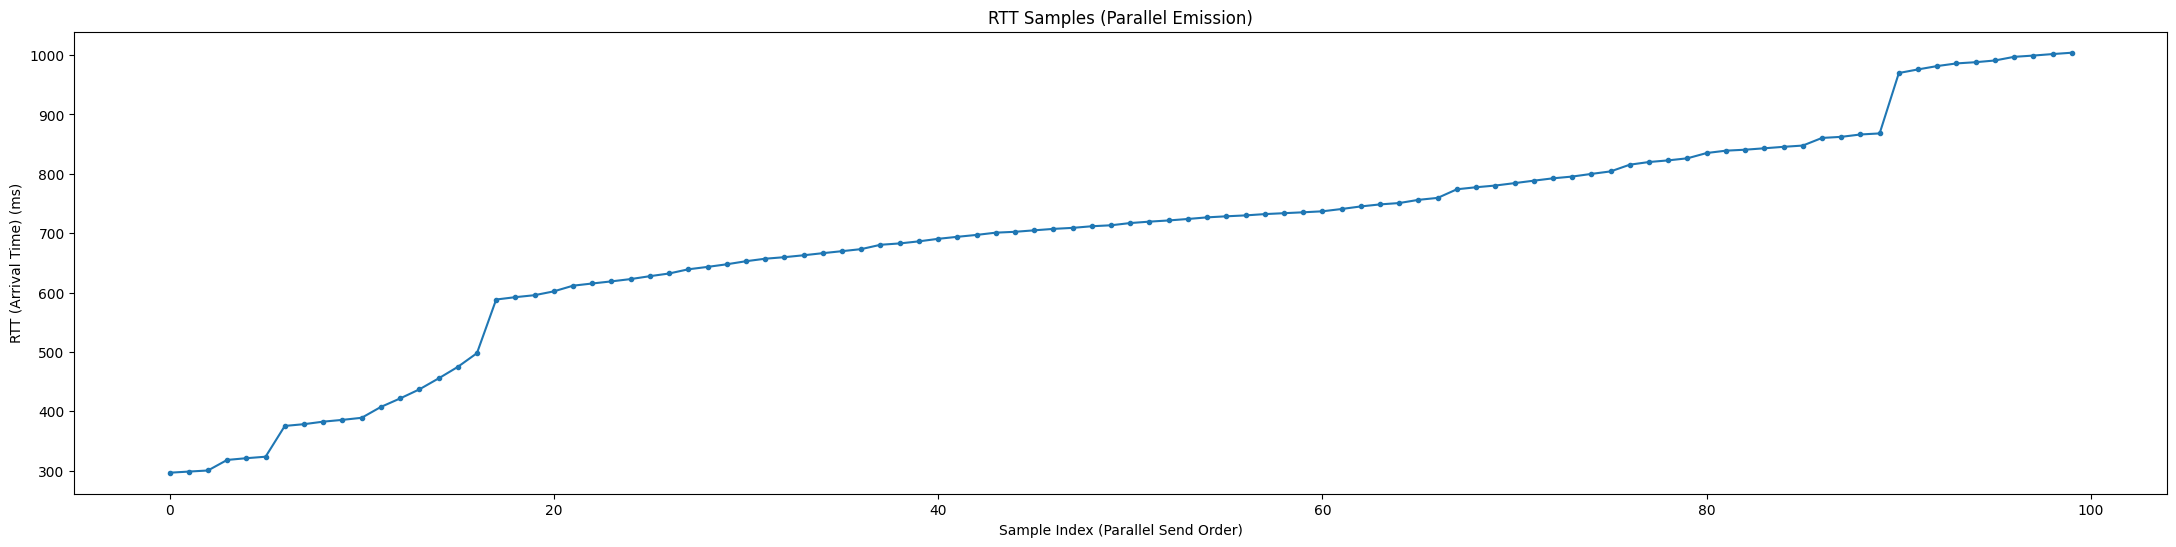

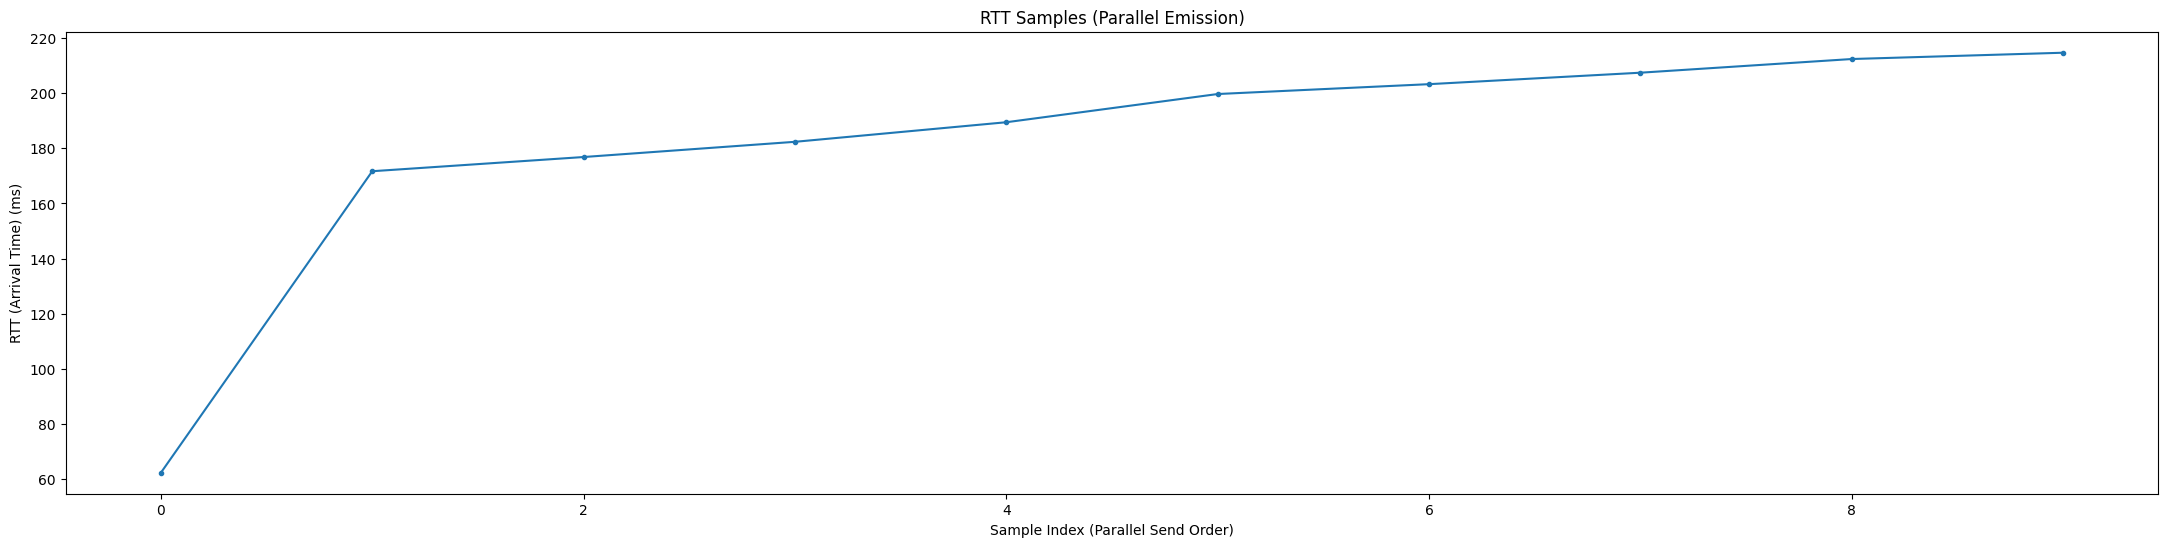

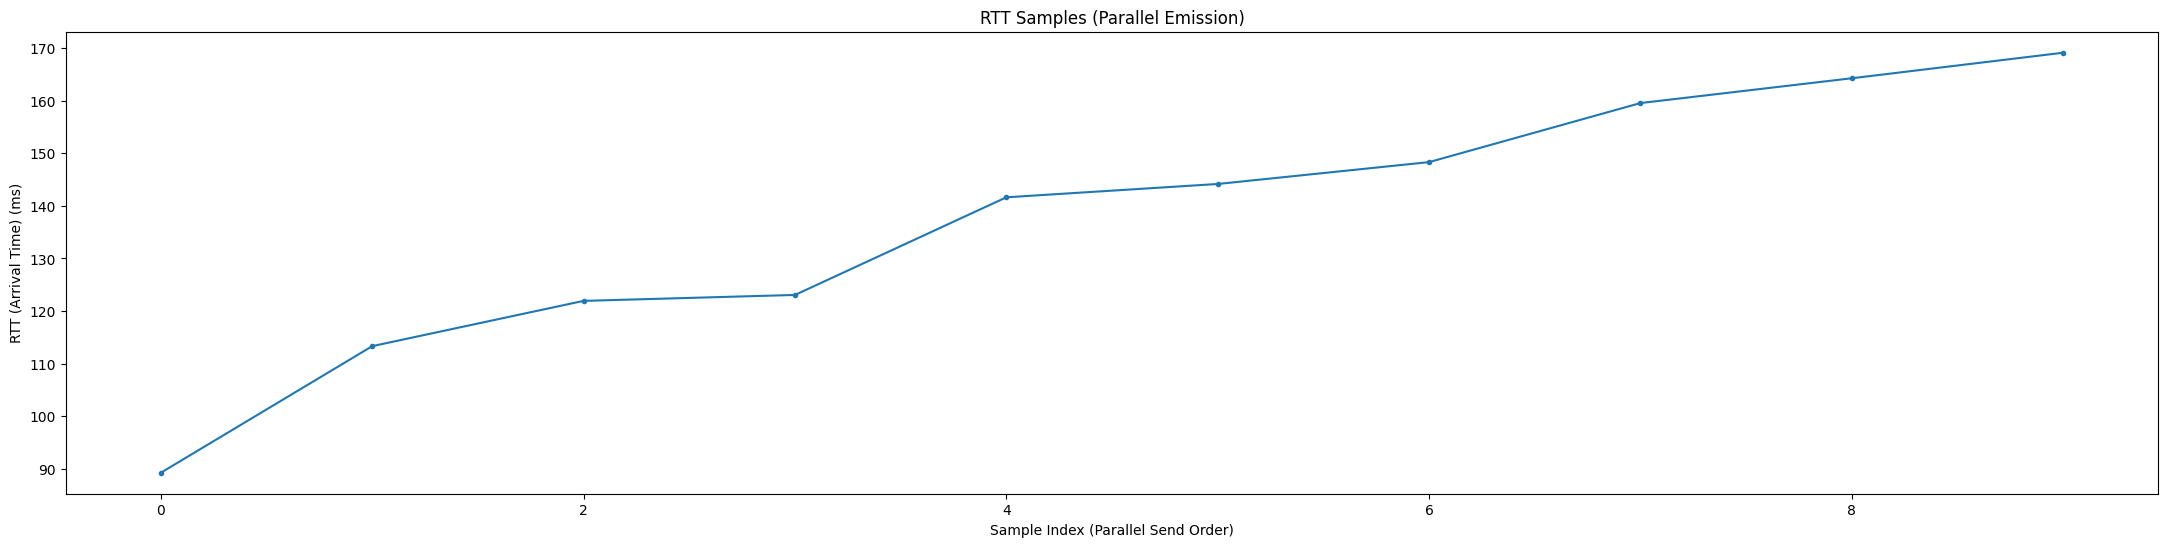

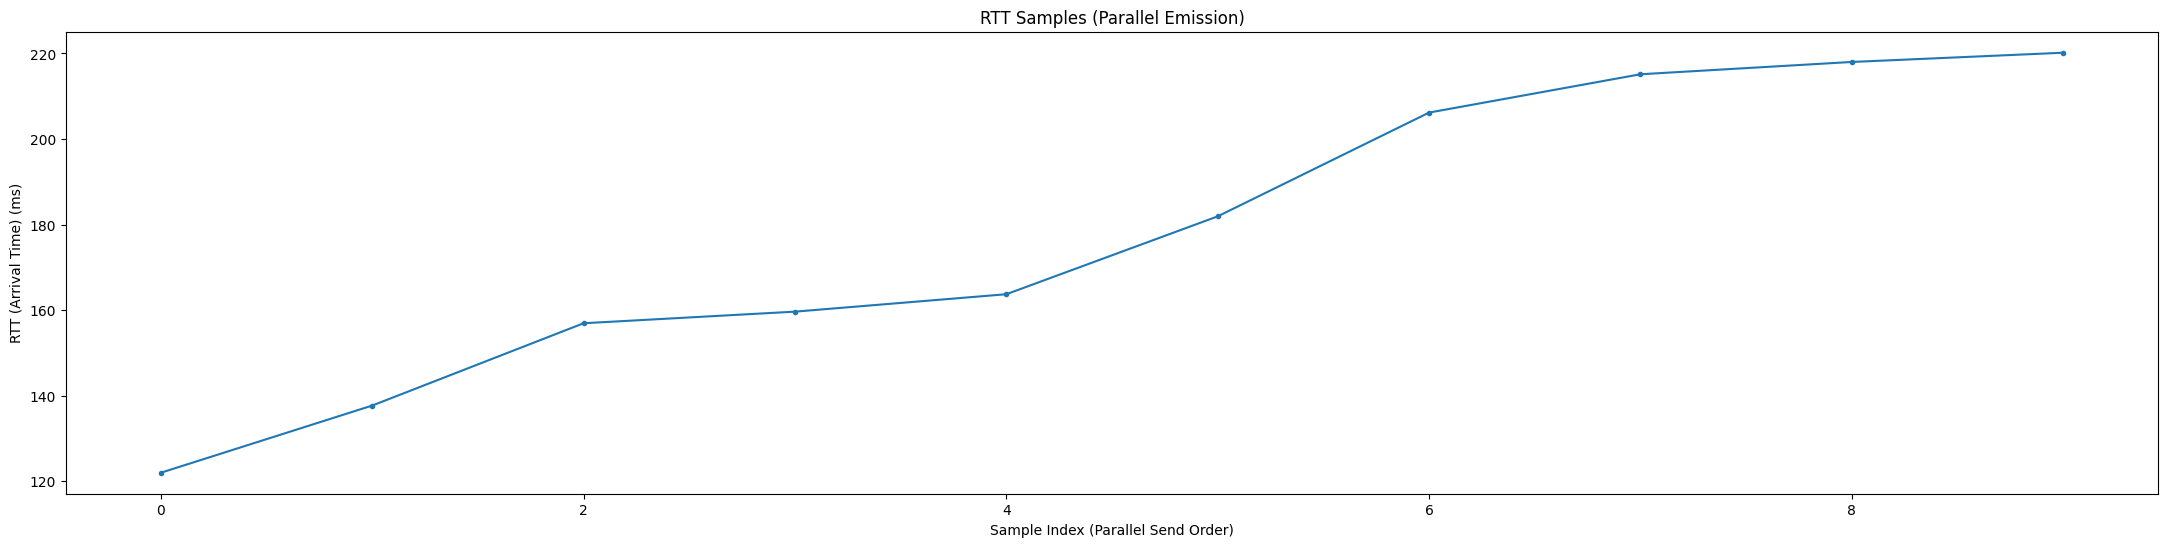

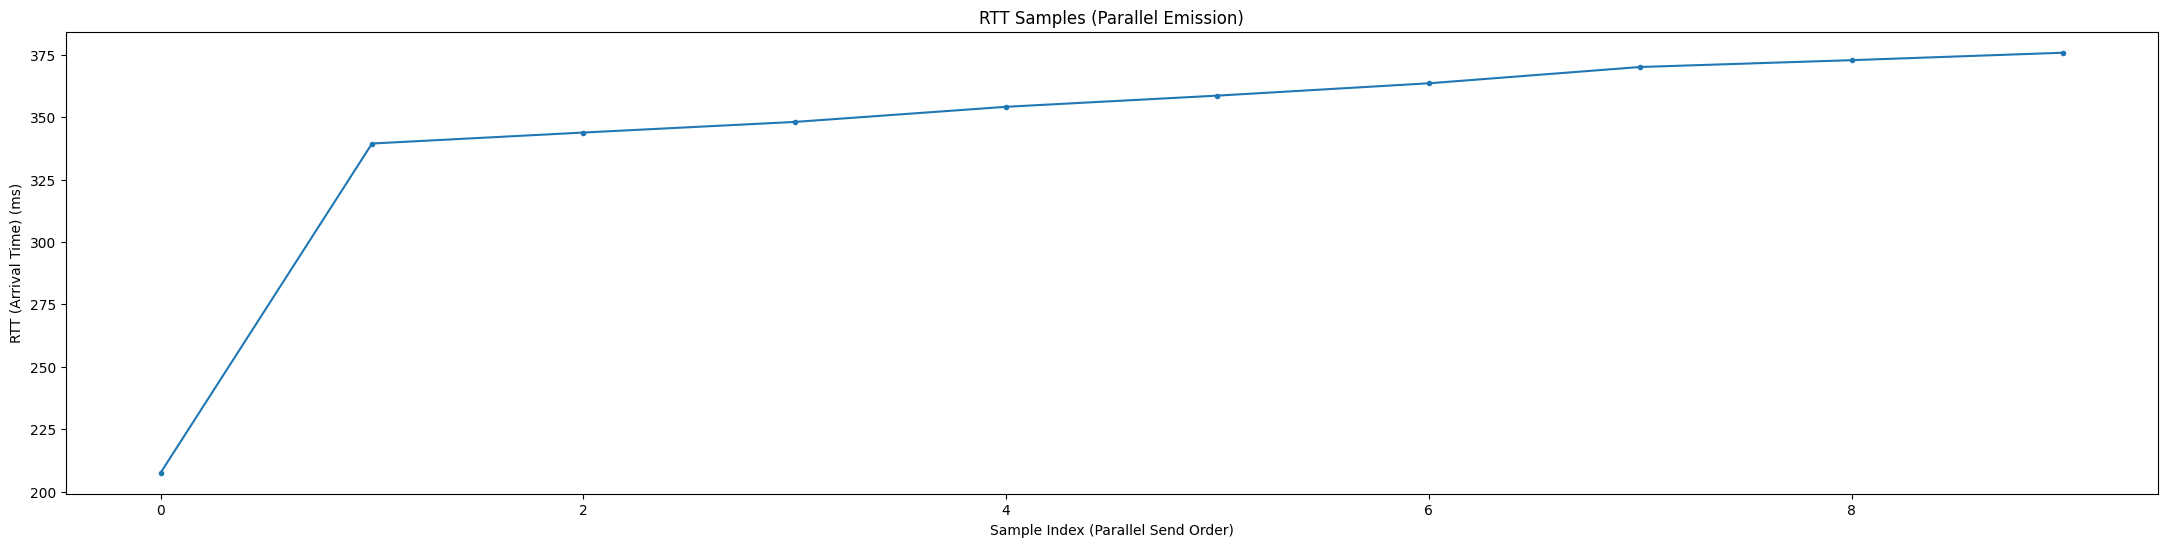

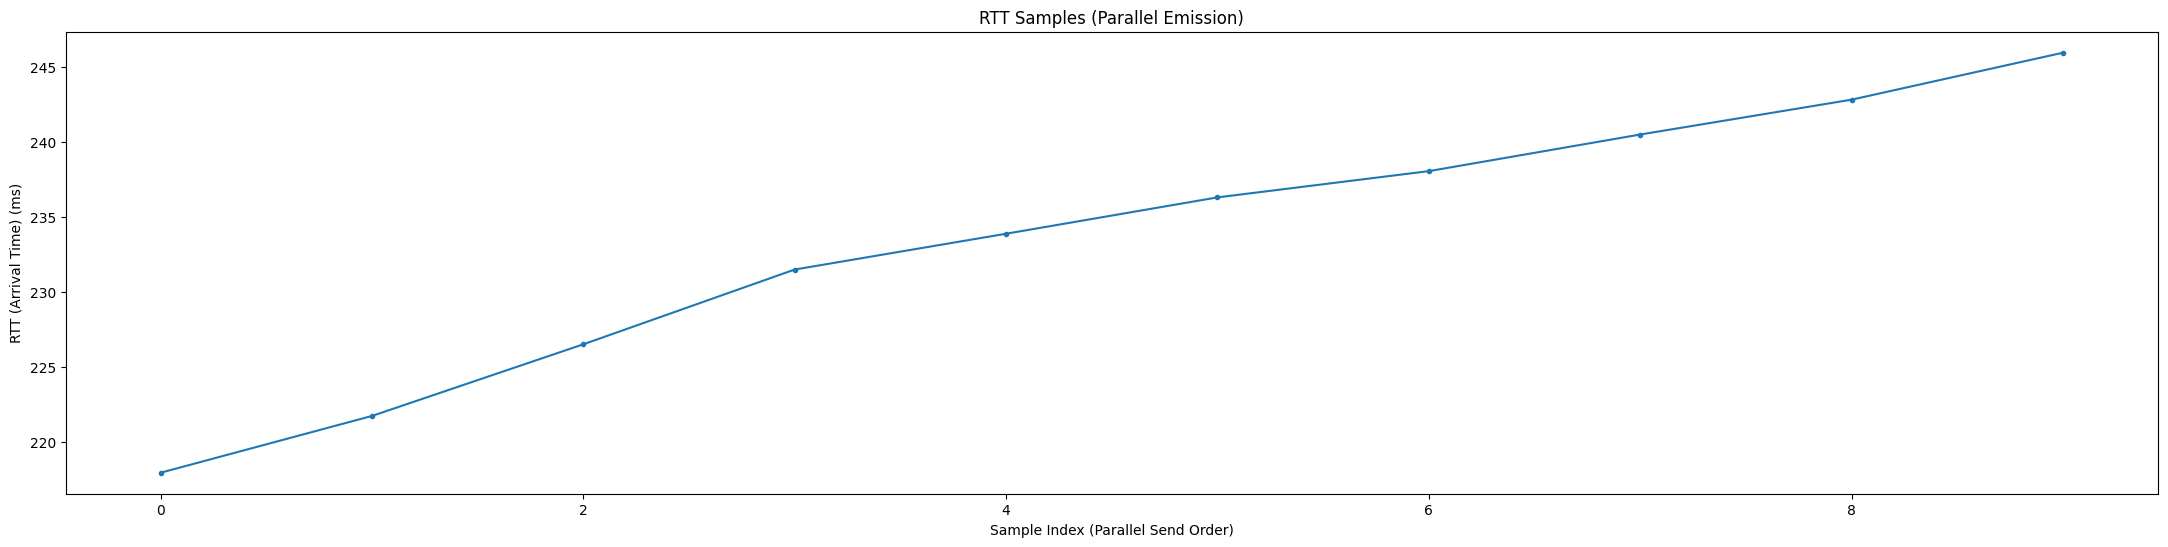

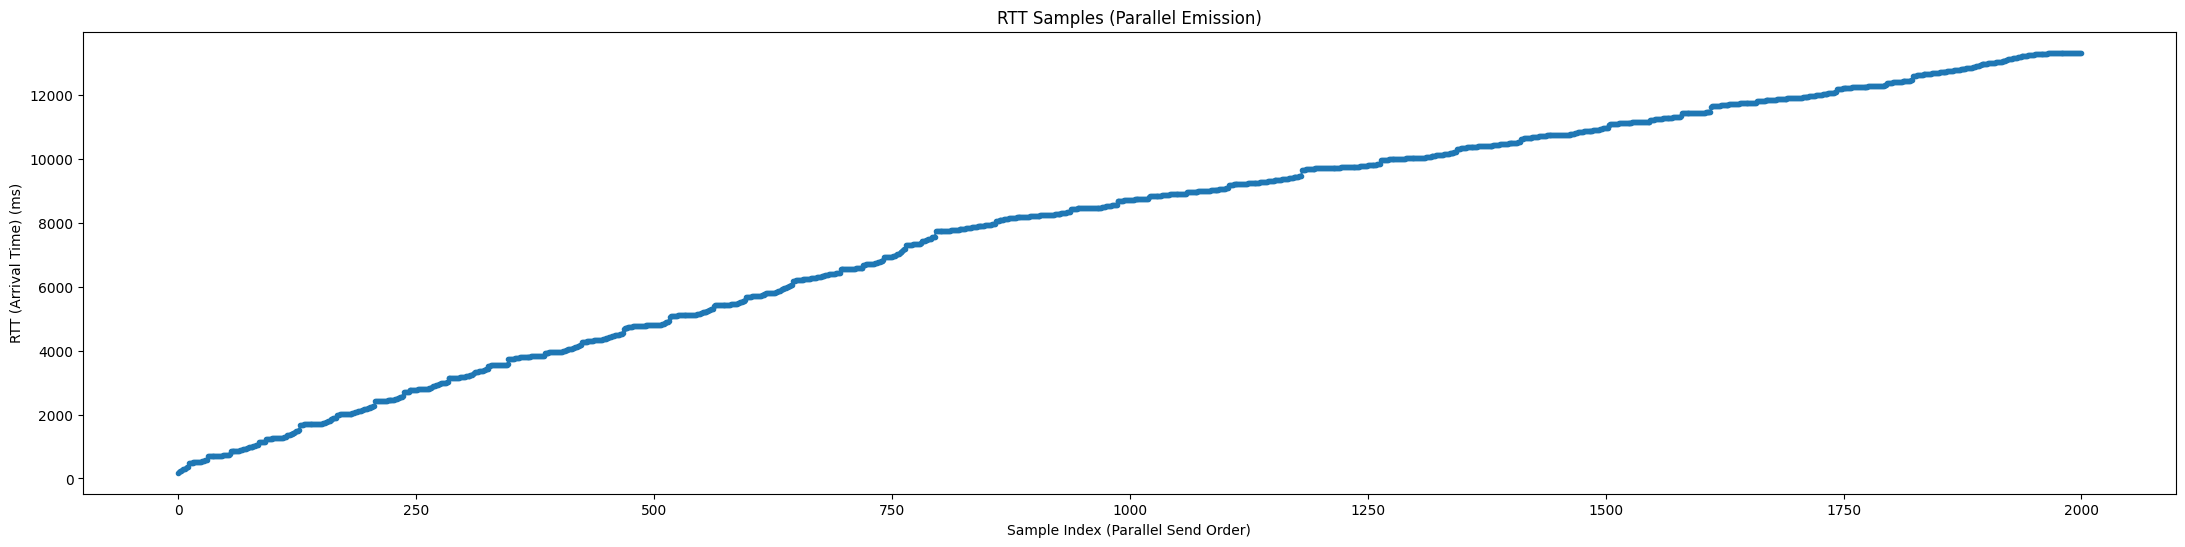

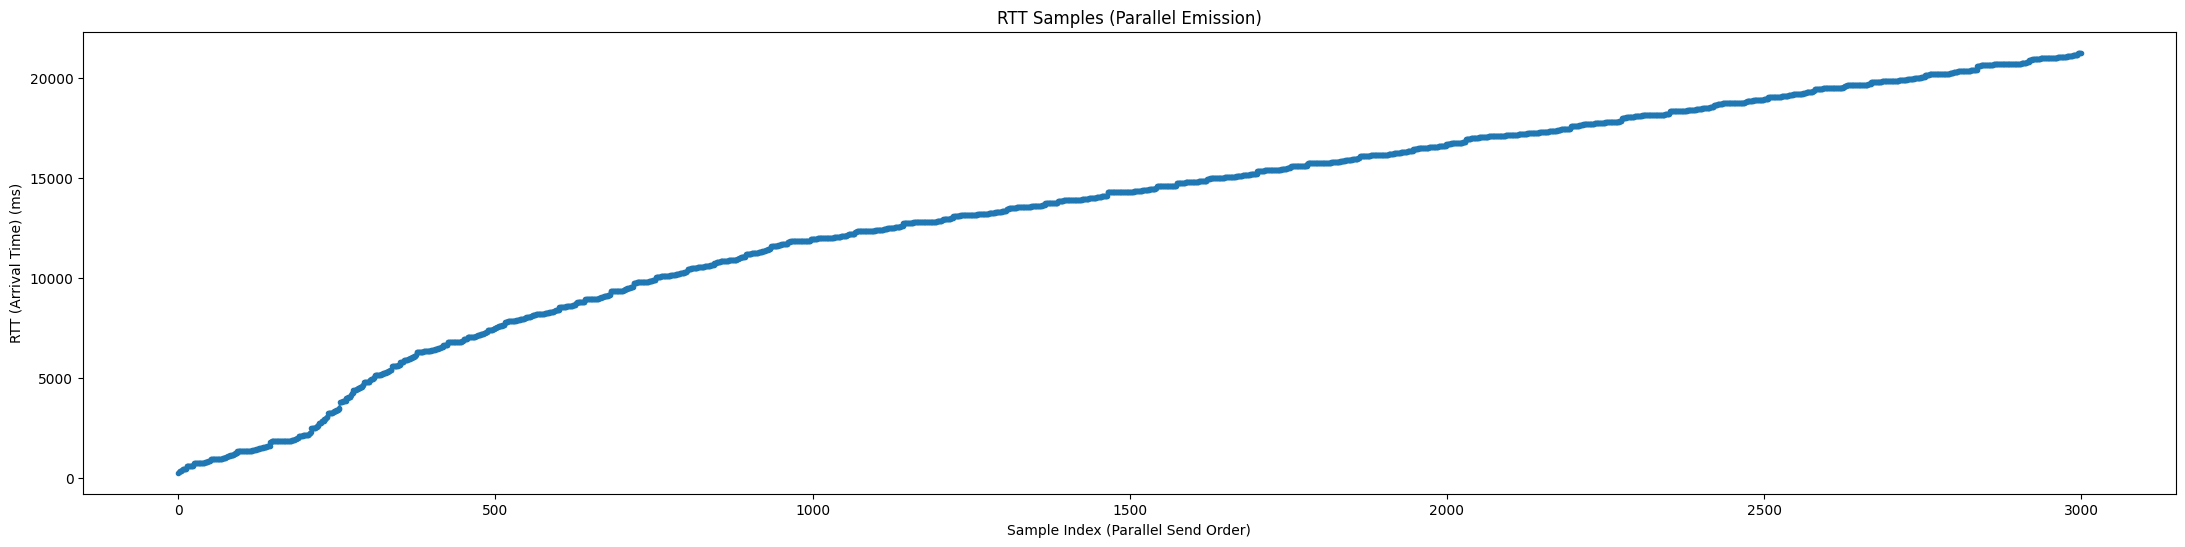

In [109]:
for _, row in df_metrics.iterrows():
    latencies = np.array(row["latency_samples"], dtype=float)

    if len(latencies) <= 2:
        continue


    if row["emission_mode"] == "SERIES":
        # Time axis: cumulative RTT, sequential emission
        time_ms = np.concatenate([[0], np.cumsum(latencies[:-1])])

        plt.figure(figsize=(27, 6))
        plt.plot(time_ms, latencies, marker=".", linestyle="-")

        plt.xlabel("Elapsed Time (ms)")
        plt.ylabel("RTT (ms)")
        plt.title(f"RTT Over Time (Sequential Emission)\n{row['experiment_name']}")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
        cum_mean = np.cumsum(latencies) / np.arange(1, len(latencies) + 1)
        plt.figure(figsize=(27, 6))
        plt.plot(time_ms, cum_mean, linestyle="--", label="Cumulative Mean")
        plt.grid(True)
        plt.tight_layout()
        plt.legend()
    else: #PAALLEL
        plt.figure(figsize=(27, 6))
        plt.plot(latencies, marker=".")
        plt.ylabel("RTT (Arrival Time) (ms)")
        plt.xlabel("Sample Index (Parallel Send Order)")
        plt.title("RTT Samples (Parallel Emission)")


